# Gradient Domain Editing

## 📦 Packages

In [1]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

## 🚙 Utilities

In [2]:
def show(i, title: str = "Color Image"):
    t = "gray" if i.ndim == 2 else "color"
    
    if t == "color":
        # color
        plt.imshow(cv2.cvtColor(src=i, code=cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.show()
    else:
        # gray
        plt.imshow(i, cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.show()
    

def side2side(i1, i2):
    plt.figure(figsize=(10, 5))
    
    t1 = "gray" if i1.ndim == 2 else "color"
    t2 = "gray" if i2.ndim == 2 else "color"
    
    # color/gray
    plt.subplot(1, 2, 1)
    plt.title(t1)
    if t1 == "gray":
        plt.imshow(X=i1, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i1, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    
    
    # color/gray
    plt.subplot(1, 2, 2)
    plt.title(t2)
    if t2 == "gray":
        plt.imshow(X=i2, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i2, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    

def store(image, file):
    cv2.imwrite(filename=file, img=image)
    

def use_this_to_determine_the_mask_region(image):
    cv2.namedWindow(winname="Use this to determine the region for mask", flags=cv2.WINDOW_NORMAL)
    cv2.imshow(winname="Use this to determine the region for mask", mat=image)
    cv2.waitKey(-1)
    cv2.destroyAllWindows()

## 🧑‍💻 Codes

### 🖼️ Images

#### Path

In [3]:
sudoku_path = Path("..") / "data" / "input" / "sudoku.jpg"

In [4]:
eye_path = Path("..") / "data" / "input" / "eye_of_providence.webp"
pyramid_path = Path("..") / "data" / "input" / "pyramid.jpg"

#### Images

In [5]:
sudoku = cv2.imread(filename=sudoku_path.as_posix())
sudoku = cv2.cvtColor(sudoku, cv2.COLOR_BGR2GRAY)

eye = cv2.imread(eye_path)
# eye = cv2.cvtColor(eye, cv2.COLOR_BGR2GRAY)
eye = cv2.resize(eye, dsize=(200, 200))

pyramid = cv2.imread(pyramid_path)
# pyramid = cv2.cvtColor(pyramid, cv2.COLOR_BGR2GRAY)
pyramid = cv2.resize(pyramid, dsize=(500, 500))

In [6]:
eye.shape

(200, 200, 3)

In [7]:
pyramid.shape

(500, 500, 3)

In [8]:
# width: 110 -> 180 // 70
# height: 110 -> 180 // 70
# center = 150

# mask x: 60 -> 140
#      y: 40 -> 110
use_this_to_determine_the_mask_region(pyramid)

### 🤡 Understand Laplacian

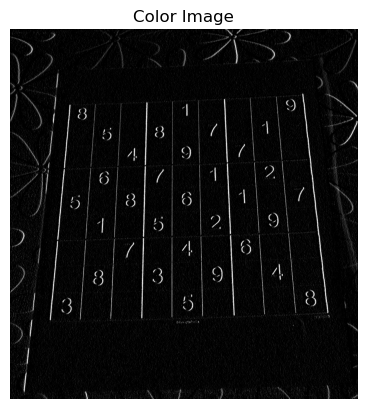

In [9]:
sudoku_sobel_x = cv2.Sobel(sudoku, ddepth=-1, dx=1, dy=0)

show(sudoku_sobel_x)

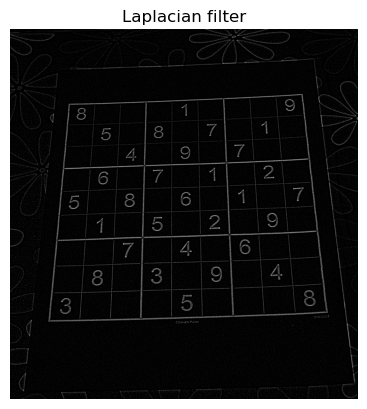

In [10]:
sudoku_gaussion = cv2.GaussianBlur(sudoku, (5, 5), 0)
sudoku_laplacian = cv2.Laplacian(sudoku_gaussion, ddepth=-1)
sudoku_laplacian = cv2.convertScaleAbs(sudoku_laplacian, dst=-1)

show(sudoku_laplacian, title="Laplacian filter")

### 🌀 Seamless cloning

In [26]:
mask = np.zeros(shape=eye.shape, dtype=np.uint8)

mask[20:160, 50:160] = 255

center = (250, 250)

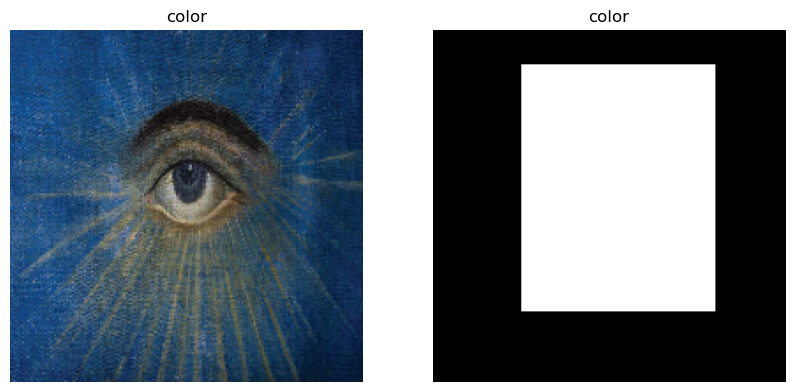

In [27]:
side2side(eye, mask)

In [28]:
eye.dtype == np.uint8 and pyramid.dtype == np.uint8 and mask.dtype == np.uint8

True

In [29]:
seamless_cloning_result = cv2.seamlessClone(eye, pyramid, mask, center, cv2.NORMAL_CLONE)

seamless_cloning_result.shape

(500, 500, 3)

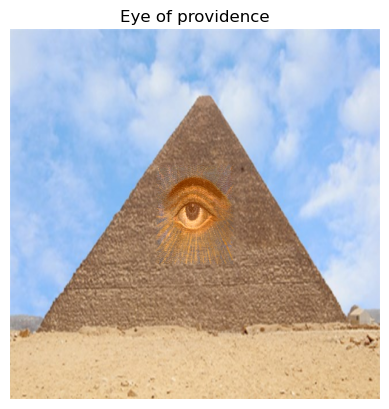

In [31]:
show(seamless_cloning_result, title="Eye of providence")